<a href="https://colab.research.google.com/github/DarleneJD/ACOPF/blob/main/CurvasVoltVarTrifasico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DATA: 13/03/2026**
**REDE: 13 BARRAS DE BAIXA TENSÃO TRIFÁSICA DESBALANCEADA**

**FUNÇÃO:** avaliar o sistema com controle Volt-Var por meio da curva dos inversores.

**CURVA:** curva geral IEEE 1547.

**OBJETIVO:** minimizar as perdas elétricas por meio da função objetivo.

### **MODELO TRIFÁSICO DESBALANCEADO**

Rede radial de baixa tensão com 5 barras (400 V / 250 kVA), conectada a uma rede de média tensão de 20 kV por meio de um transformador. O sistema é modelado como **trifásico desbalanceado por fase**, de modo que cada barra possui variáveis elétricas independentes para as fases (a), (b) e (c), permitindo representar explicitamente assimetrias de carga, geração fotovoltaica e tensão.

As barras 1, 2 e 4 possuem **carga e geração fotovoltaica trifásicas**, com a potência total dividida igualmente entre as três fases. As barras 3 e 5 possuem **carga e geração fotovoltaica monofásicas**, conectadas a uma fase específica, enquanto as demais fases dessas barras permanecem sem injeção de potência ativa e reativa associada a esses elementos.

O problema é formulado como um **OPF (Optimal Power Flow)** na forma de **MINLP**, implementado em **Pyomo** e resolvido com o **BONMIN**. A modelagem elétrica utiliza equações do tipo **DistFlow por fase**, com variáveis de fluxo ativo, fluxo reativo, corrente ao quadrado e magnitude de tensão ao quadrado para cada ramo e fase da rede. Nesta formulação, cada fase é representada separadamente, permitindo capturar o comportamento desbalanceado do sistema.

A **função objetivo** minimiza as **perdas totais ativas da rede**, calculadas pela soma das perdas em todos os ramos e em todas as fases.

O controle **Volt-Var**, conforme a **IEEE 1547-2018**, é implementado **por barra e por fase**, ou seja, cada inversor responde à tensão local da fase à qual está conectado. A curva Volt-Var é representada com variáveis binárias e restrições do tipo **Big-M**, considerando cinco regiões operativas delimitadas pelos pontos:

* ($V_{1}$ = 0.92) pu
* ($V_{2}$ = 0.98) pu
* ($V_{3}$ = 1.02) pu
* ($V_{4}$ = 1.08) pu

Com isso, cada unidade fotovoltaica pode injetar ou absorver potência reativa de acordo com a tensão local da fase, respeitando seus limites de capacidade reativa.

As bases adotadas no sistema são:

* **potência base trifásica:** ($S_{base}$ = 250 kVA)
* **potência base por fase:** ($S_{base,1\phi}$ = $\frac{250}{3}$ kVA)
* **tensão base na baixa tensão:** ($V_{base}$ = 400  V) fase-fase

Nesta versão, o modelo representa a rede como **trifásica desbalanceada por fase**, com controle Volt-Var individual por fase, tornando a formulação coerente com a presença simultânea de elementos trifásicos e monofásicos ao longo do alimentador.



# Bibliotecas




In [89]:
%%capture
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'


In [90]:
# import shutil
# import sys
# import os.path

# if not shutil.which("pyomo"):
#     !pip install -q pyomo
#     assert(shutil.which("pyomo"))

# if not (shutil.which("ipopt") or os.path.isfile("ipopt")):
#     if "google.colab" in sys.modules:
#         !wget -N -q "https://matematica.unipv.it/gualandi/solvers/ipopt-linux64.zip"
#         !unzip -o -q ipopt-linux64
#     else:
#         try:
#             !conda install -c conda-forge ipopt
#         except:
#             pass


In [91]:
!rm -rf ACOPF
!git clone https://github.com/DarleneJD/ACOPF.git

Cloning into 'ACOPF'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 211 (delta 32), reused 0 (delta 0), pack-reused 153 (from 1)
Receiving objects: 100% (211/211), 1.49 MiB | 9.43 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [92]:
import sys
import os
from re import I
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt



# Dados de entrada

In [93]:

# ============================================================
# LEITURA
# ============================================================
base_path = "/content/ACOPF"
controle = f"{base_path}/volt-var.xlsx"

df_bus_bt = pd.read_excel(controle, sheet_name="bus_BT")
df_pv_bt = pd.read_excel(controle, sheet_name="bus_PV")
df_branches_bt = pd.read_excel(controle, sheet_name="branches_BT")


In [94]:

# padronização de colunas
df_bus_bt.columns = df_bus_bt.columns.str.strip()
df_pv_bt.columns = df_pv_bt.columns.str.strip()
df_branches_bt.columns = df_branches_bt.columns.str.strip()

# ============================================================
# CONSTANTES GERAIS
# ============================================================
PHASES = ["a", "b", "c"]
PHASE_MAP = {"1": "a", "2": "b", "3": "c"}

SLACK_BUS = "SOURCE"

FP_CARGA = 0.9
ANGULO_CARGA = np.arccos(FP_CARGA)

V_SLACK_PU = 1.02
vmin, vmax = 0.90, 1.20

FATOR_CARGA = 0.5
FATOR_PV = 1.0

# curva Volt-Var
V1, V2, V3, V4 = 0.92, 0.98, 1.02, 1.08
V1_2, V2_2, V3_2, V4_2 = V1**2, V2**2, V3**2, V4**2
M_bigm = 5.0

# base elétrica
PERCENT_R_TRAFO = 1.91
PERCENT_X_TRAFO = 3.51
S_base_3ph = 250.0
S_base_1ph = S_base_3ph / 3.0

# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================
def parse_conn(phases_value):
    """
    Retorna:
    - conn_type: 'three_phase' ou 'single_phase'
    - conn_phase: 'a','b','c' ou None
    """
    s = str(phases_value).strip()

    if s == "1,2,3":
        return "three_phase", None
    if s in PHASE_MAP:
        return "single_phase", PHASE_MAP[s]

    raise ValueError(f"Valor inválido em 'phases': {phases_value}")


def safe_float(x, default=0.0):
    if pd.isna(x):
        return default
    return float(x)


def dividir_carga_por_fase(total_kw, bus, phase):
    """
    Divide carga agregada da barra por fase.
    """
    bus_type = BUS_TYPE[bus]
    bus_phase = BUS_PHASE[bus]

    if bus_type == "three_phase":
        return total_kw / 3.0
    if bus_type == "single_phase":
        return total_kw if phase == bus_phase else 0.0

    raise ValueError(f"Tipo de barra inválido: {bus}")


def calc_limites_qpv_por_fase(bus, phase, p_pv_1f_kw):
    """
    Limites Q do inversor por fase, em kVAr.
    Usa os dados já carregados por barra-fase.
    """
    p_nom_1f = P_PV_NOMINAL.get((bus, phase), 0.0)
    q_nom_1f = Q_PV_RATED.get((bus, phase), 0.0)
    s_nom_1f = S_PV_NOMINAL.get((bus, phase), 0.0)

    if p_nom_1f <= 1e-12 or q_nom_1f <= 1e-12 or s_nom_1f <= 1e-12:
        return 0.0, 0.0

    p1 = 0.05 * p_nom_1f
    p2 = 0.20 * p_nom_1f

    if p_pv_1f_kw < p1:
        qmax = 0.0
    elif p_pv_1f_kw >= p2:
        qmax = q_nom_1f
    else:
        qmax = 2.2 * s_nom_1f * (p_pv_1f_kw / p_nom_1f)

    return -qmax, qmax

In [95]:
# Padronização das fases,
def parse_conn(phases_value):
    """
    Converte a coluna 'phases' para:
    - conn_type: 'three_phase' ou 'single_phase'
    - conn_phase: 'a','b','c' ou None
    """
    s = str(phases_value).strip()

    if s == "1,2,3":
        return "three_phase", None

    if s in PHASE_MAP:
        return "single_phase", PHASE_MAP[s]

    raise ValueError(f"Valor inválido em 'phases': {phases_value}")


def safe_float(x, default=0.0):
    if pd.isna(x):
        return default
    return float(x)

### BUS BT

In [96]:
# ============================================================
# BARRAS BT
# ============================================================
BUS_NAME_TO_N = {}
BUS_N_TO_NAME = {}

BUS_TYPE = {}
BUS_PHASE = {}
V_NOM_KV_FN = {}

P_CARGA_NOMINAL_BARRA = {}
Q_CARGA_NOMINAL_BARRA = {}

buses_bt = []

for _, row in df_bus_bt.iterrows():
    bus_n = int(row["N"])
    bus_name = str(row["name"]).strip()

    conn_type, conn_phase = parse_conn(row["phases"])

    BUS_NAME_TO_N[bus_name] = bus_n
    BUS_N_TO_NAME[bus_n] = bus_name

    BUS_TYPE[bus_name] = conn_type
    BUS_PHASE[bus_name] = conn_phase
    V_NOM_KV_FN[bus_name] = safe_float(row["v_nom_kv"])

    P_CARGA_NOMINAL_BARRA[bus_name] = safe_float(row["P_D"])
    Q_CARGA_NOMINAL_BARRA[bus_name] = safe_float(row["Q_D"])

    buses_bt.append(bus_name)

buses_bt = sorted(set(buses_bt))

### Planilha PV

In [97]:
# ============================================================
# PV POR BARRA-FASE
# ============================================================
df_pv_bt["Bus"] = df_pv_bt["Bus"].astype(str).str.strip()
df_pv_bt["phases"] = df_pv_bt["phases"].astype(str).str.strip()

PV_TYPE = {}
PV_PHASE = {}

P_PV_NOMINAL = {}
Q_PV_RATED = {}
S_PV_NOMINAL = {}

# inicializa todas as barras/fases com zero
for bus in buses_bt:
    PV_TYPE[bus] = None
    PV_PHASE[bus] = None
    for ph in PHASES:
        P_PV_NOMINAL[(bus, ph)] = 0.0
        Q_PV_RATED[(bus, ph)] = 0.0
        S_PV_NOMINAL[(bus, ph)] = 0.0

# sobrescreve onde houver PV
for _, row in df_pv_bt.iterrows():
    bus = row["Bus"]
    conn_type, conn_phase = parse_conn(row["phases"])

    PV_TYPE[bus] = conn_type
    PV_PHASE[bus] = conn_phase

    kva_total = safe_float(row["kva"])

    p_by_phase = {
        "a": safe_float(row["p_pv_1"]),
        "b": safe_float(row["p_pv_2"]),
        "c": safe_float(row["p_pv_3"]),
    }

    q_by_phase = {
        "a": safe_float(row["q_pv_1"]),
        "b": safe_float(row["q_pv_2"]),
        "c": safe_float(row["q_pv_3"]),
    }

    if conn_type == "three_phase":
        for ph in PHASES:
            P_PV_NOMINAL[(bus, ph)] = p_by_phase[ph]
            Q_PV_RATED[(bus, ph)] = q_by_phase[ph]
            S_PV_NOMINAL[(bus, ph)] = kva_total / 3.0
    else:
        for ph in PHASES:
            if ph == conn_phase:
                P_PV_NOMINAL[(bus, ph)] = p_by_phase[ph]
                Q_PV_RATED[(bus, ph)] = q_by_phase[ph]
                S_PV_NOMINAL[(bus, ph)] = kva_total

### Branches

In [98]:
# ============================================================
# RAMOS BT
# ============================================================
LINES_BT = []
BRANCH_TYPE = {}
BRANCH_PHASE = {}
R_LINE = {}
X_LINE = {}
IMAX_LINE = {}
LENGTH_M = {}

for _, row in df_branches_bt.iterrows():
    from_bus = str(row["l"]).strip()
    to_bus = str(row["k"]).strip()

    conn_type, conn_phase = parse_conn(row["phase"])

    LINES_BT.append((from_bus, to_bus))
    BRANCH_TYPE[(from_bus, to_bus)] = conn_type
    BRANCH_PHASE[(from_bus, to_bus)] = conn_phase

    R_LINE[(from_bus, to_bus)] = safe_float(row["R"])
    X_LINE[(from_bus, to_bus)] = safe_float(row["X"])
    IMAX_LINE[(from_bus, to_bus)] = safe_float(row["Imax"])
    LENGTH_M[(from_bus, to_bus)] = safe_float(row["Length_m"])

LINES_BT = list(dict.fromkeys(LINES_BT))

### Topologia

In [99]:
# ============================================================
# TOPOLOGIA GLOBAL
# ============================================================
from_set = {i for i, j in LINES_BT}
to_set = {j for i, j in LINES_BT}

ROOTS_BT = sorted(from_set - to_set)
print("Raízes BT:", ROOTS_BT)

TRAFO_CONN = [(SLACK_BUS, root) for root in ROOTS_BT]
ALL_CONN = TRAFO_CONN + LINES_BT

UPSTREAM = {}
DOWNSTREAM = {bus: [] for bus in buses_bt}
DOWNSTREAM[SLACK_BUS] = []

for i, j in LINES_BT:
    UPSTREAM[j] = (i, j)
    DOWNSTREAM[i].append((i, j))

for root in ROOTS_BT:
    UPSTREAM[root] = (SLACK_BUS, root)
    DOWNSTREAM[SLACK_BUS].append((SLACK_BUS, root))

Raízes BT: ['B010', 'B020', 'B030', 'B040', 'B050', 'B060', 'B070', 'B080', 'B090', 'B100', 'B110']


### Bases Elétricas

In [100]:
# ============================================================
# BASES ELÉTRICAS
# ============================================================
# assumindo v_nom_kv em fase-neutro
V_BT_LN = list(V_NOM_KV_FN.values())[0]
V_BT_LL = V_BT_LN * np.sqrt(3)

Z_base_Ohm = ((V_BT_LL ** 2) / S_base_3ph) * 1000

R_TRAFO_Ohm = (PERCENT_R_TRAFO / 100.0) * Z_base_Ohm
X_TRAFO_Ohm = (PERCENT_X_TRAFO / 100.0) * Z_base_Ohm

R_TRAFO_1ph_Ohm = R_TRAFO_Ohm / 3.0
X_TRAFO_1ph_Ohm = X_TRAFO_Ohm / 3.0

R_TRAFO_pu = R_TRAFO_1ph_Ohm / Z_base_Ohm
X_TRAFO_pu = X_TRAFO_1ph_Ohm / Z_base_Ohm

R_LINE_PU = {k: v / Z_base_Ohm for k, v in R_LINE.items()}
X_LINE_PU = {k: v / Z_base_Ohm for k, v in X_LINE.items()}

R_CONN_PU = dict(R_LINE_PU)
X_CONN_PU = dict(X_LINE_PU)

for root in ROOTS_BT:
    R_CONN_PU[(SLACK_BUS, root)] = R_TRAFO_pu
    X_CONN_PU[(SLACK_BUS, root)] = X_TRAFO_pu

#### Mascaras

In [101]:
# ============================================================
# MÁSCARAS DE FASES EXISTENTES
# ============================================================
def phase_exists_bus(bus, ph):
    if bus == SLACK_BUS:
        return True
    if BUS_TYPE[bus] == "three_phase":
        return True
    return BUS_PHASE[bus] == ph


def phase_exists_branch(i, j, ph):
    if (i, j) in TRAFO_CONN:
        return True
    if BRANCH_TYPE[(i, j)] == "three_phase":
        return True
    return BRANCH_PHASE[(i, j)] == ph

### Parametros barra/fase

In [102]:
# ============================================================
# PARÂMETROS POR BARRA-FASE
# ============================================================
P_carga_fase = {}
Q_carga_fase = {}
P_pv_fase = {}
Qmin_fase = {}
Qmax_fase = {}

for bus in buses_bt:
    p_carga_total = P_CARGA_NOMINAL_BARRA.get(bus, 0.0) * FATOR_CARGA
    q_carga_total = Q_CARGA_NOMINAL_BARRA.get(bus, 0.0) * FATOR_CARGA

    print(f"\nBarra {bus}")

    for ph in PHASES:
        # carga
        p_carga_1f = dividir_carga_por_fase(p_carga_total, bus, ph)
        q_carga_1f = dividir_carga_por_fase(q_carga_total, bus, ph)

        P_carga_fase[(bus, ph)] = p_carga_1f / S_base_1ph
        Q_carga_fase[(bus, ph)] = q_carga_1f / S_base_1ph

        # PV já vem por fase
        p_pv_1f = P_PV_NOMINAL.get((bus, ph), 0.0) * FATOR_PV
        P_pv_fase[(bus, ph)] = p_pv_1f / S_base_1ph

        qmin_1f, qmax_1f = calc_limites_qpv_por_fase(bus, ph, p_pv_1f)
        Qmin_fase[(bus, ph)] = qmin_1f / S_base_1ph
        Qmax_fase[(bus, ph)] = qmax_1f / S_base_1ph

        print(
            f"  fase {ph}: "
            f"Pcarga={p_carga_1f:8.3f} kW | "
            f"Qcarga={q_carga_1f:8.3f} kVAr | "
            f"Ppv={p_pv_1f:8.3f} kW | "
            f"Qpv±={qmax_1f:8.3f} kVAr"
        )


Barra B010
  fase a: Pcarga=   0.000 kW | Qcarga=   0.000 kVAr | Ppv=   0.000 kW | Qpv±=   0.000 kVAr
  fase b: Pcarga=   0.000 kW | Qcarga=   0.000 kVAr | Ppv=   0.000 kW | Qpv±=   0.000 kVAr
  fase c: Pcarga=   0.000 kW | Qcarga=   0.000 kVAr | Ppv=   0.000 kW | Qpv±=   0.000 kVAr

Barra B011
  fase a: Pcarga=  16.667 kW | Qcarga=   5.000 kVAr | Ppv=  25.261 kW | Qpv±=   0.000 kVAr
  fase b: Pcarga=  16.667 kW | Qcarga=   5.000 kVAr | Ppv=  25.261 kW | Qpv±=   0.000 kVAr
  fase c: Pcarga=  16.667 kW | Qcarga=   5.000 kVAr | Ppv=  25.261 kW | Qpv±=   0.000 kVAr

Barra B012
  fase a: Pcarga=  16.667 kW | Qcarga=   5.000 kVAr | Ppv=  25.261 kW | Qpv±=   0.000 kVAr
  fase b: Pcarga=  16.667 kW | Qcarga=   5.000 kVAr | Ppv=  25.261 kW | Qpv±=   0.000 kVAr
  fase c: Pcarga=  16.667 kW | Qcarga=   5.000 kVAr | Ppv=  25.261 kW | Qpv±=   0.000 kVAr

Barra B013
  fase a: Pcarga=  16.667 kW | Qcarga=   5.000 kVAr | Ppv=  25.261 kW | Qpv±=   0.000 kVAr
  fase b: Pcarga=  16.667 kW | Qcarga=   5

In [103]:
print("=" * 70)
print("SISTEMA TRIFÁSICO DESBALANCEADO POR FASE")
print("=" * 70)
print(f"V_BT_FF = {V_BT_LL*1000:.0f} V |")
print(f"S_base_3f = {S_base_3ph:.2f} kVA | S_base_1f = {S_base_1ph:.4f} kVA")
print(f"Z_base = {Z_base_Ohm:.4f} ohm")
print(f"R_TRAFO_pu = {R_TRAFO_pu:.6f}")
print(f"X_TRAFO_pu = {X_TRAFO_pu:.6f}")
print(f"R_LINE_PU = {R_LINE_PU}")
print(f"X_LINE_PU = {X_LINE_PU}")

SISTEMA TRIFÁSICO DESBALANCEADO POR FASE
V_BT_FF = 831 V |
S_base_3f = 250.00 kVA | S_base_1f = 83.3333 kVA
Z_base = 2.7648 ohm
R_TRAFO_pu = 0.006367
X_TRAFO_pu = 0.011700
R_LINE_PU = {('B010', 'B011'): np.float64(0.0006872106481481484), ('B011', 'B012'): np.float64(0.0006872106481481484), ('B012', 'B013'): np.float64(0.0006872106481481484), ('B013', 'B014'): np.float64(0.0006872106481481484), ('B020', 'B021'): np.float64(0.0006872106481481484), ('B021', 'B022'): np.float64(0.0006872106481481484), ('B022', 'B023'): np.float64(0.0006872106481481484), ('B023', 'B024'): np.float64(0.0006872106481481484), ('B030', 'B031'): np.float64(0.0006872106481481484), ('B031', 'B032'): np.float64(0.0006872106481481484), ('B032', 'B033'): np.float64(0.0006872106481481484), ('B033', 'B034'): np.float64(0.0006872106481481484), ('B040', 'B041'): np.float64(0.0006872106481481484), ('B041', 'B042'): np.float64(0.0006872106481481484), ('B042', 'B043'): np.float64(0.0006872106481481484), ('B043', 'B044'): np

# Modelo

In [137]:
  # ============================================================
  # MODELO PYOMO
  # ============================================================
  model = pyo.ConcreteModel(name="OPF_BT_multi_feeders")


### Conjuntos

In [138]:
# ------------------------------------------------------------
# Conjuntos
# ------------------------------------------------------------
model.BUSES = pyo.Set(initialize=[SLACK_BUS] + buses_bt)
model.BUSES_BT = pyo.Set(initialize=buses_bt)
model.PHASES = pyo.Set(initialize=PHASES)
model.LINES_BT = pyo.Set(initialize=LINES_BT, dimen=2)
model.TRAFO = pyo.Set(initialize=TRAFO_CONN, dimen=2)
model.ALL_CONN = model.TRAFO | model.LINES_BT
def pv_exists(bus, ph, tol=1e-9):
    return (
        abs(P_PV_NOMINAL.get((bus, ph), 0.0)) > tol
        or abs(Q_PV_RATED.get((bus, ph), 0.0)) > tol
        or abs(S_PV_NOMINAL.get((bus, ph), 0.0)) > tol
    )

PV_BUS_PHASES = [
    (bus, ph)
    for bus in buses_bt
    for ph in PHASES
    if pv_exists(bus, ph)
]

model.PV_BUS_PHASES = pyo.Set(dimen=2, initialize=PV_BUS_PHASES)

### Parâmetros

In [139]:
model.R = pyo.Param(model.ALL_CONN, initialize=R_CONN_PU, default=0.0)
model.X = pyo.Param(model.ALL_CONN, initialize=X_CONN_PU, default=0.0)

model.P_LOAD = pyo.Param(model.BUSES_BT, model.PHASES, initialize=P_carga_fase, default=0.0)
model.Q_LOAD = pyo.Param(model.BUSES_BT, model.PHASES, initialize=Q_carga_fase, default=0.0)
model.P_PV   = pyo.Param(model.BUSES_BT, model.PHASES, initialize=P_pv_fase, default=0.0)
model.Qmax   = pyo.Param(model.BUSES_BT, model.PHASES, initialize=P_pv_fase, default=0.0) # alterado
model.Qmin   = pyo.Param(model.BUSES_BT, model.PHASES, initialize=0, default=0.0) # alterado

### Variaveis

In [140]:
vmin = 0.90
vmax = 1.10
V_SLACK_PU = 1.0
V2_slack  = V_SLACK_PU ** 2
vlimdown  = vmin ** 2
vlimup    = vmax ** 2
V_max_lin = vmax

model.V2 = pyo.Var(model.BUSES, model.PHASES, bounds=(vmin**2, vmax**2), initialize=1.0)

for ph in PHASES:
    model.V2[SLACK_BUS, ph].fix(V_SLACK_PU**2)

model.P = pyo.Var(model.ALL_CONN, model.PHASES, bounds=(-10, 10), initialize=0.0)
model.Q = pyo.Var(model.ALL_CONN, model.PHASES, bounds=(-10, 10), initialize=0.0)
model.I2 = pyo.Var(model.ALL_CONN, model.PHASES, bounds=(0, 100), initialize=0.001)

model.Q_PV = pyo.Var(
    model.BUSES_BT, model.PHASES,
    bounds=lambda m, bus, ph: (m.Qmin[bus, ph], m.Qmax[bus, ph]),
    initialize=0.0
)

model.z1 = pyo.Var(model.PV_BUS_PHASES, within=pyo.Binary, initialize=0)
model.z2 = pyo.Var(model.PV_BUS_PHASES, within=pyo.Binary, initialize=0)
model.z3 = pyo.Var(model.PV_BUS_PHASES, within=pyo.Binary, initialize=1)
model.z4 = pyo.Var(model.PV_BUS_PHASES, within=pyo.Binary, initialize=0)
model.z5 = pyo.Var(model.PV_BUS_PHASES, within=pyo.Binary, initialize=0)

model.w2 = pyo.Var(model.PV_BUS_PHASES, bounds=(0, V_max_lin), initialize=1.0)
model.w4 = pyo.Var(model.PV_BUS_PHASES, bounds=(0, V_max_lin), initialize=1.0)

### Restrições

In [141]:
# ============================================================
# DISTFLOW POR FASE
# ============================================================
def current_rule(m, i, j, ph):
    if not phase_exists_branch(i, j, ph):
        return m.I2[i, j, ph] == 0.0
    return m.I2[i, j, ph] * m.V2[i, ph] == m.P[i, j, ph]**2 + m.Q[i, j, ph]**2

model.current_eq = pyo.Constraint(model.ALL_CONN, model.PHASES, rule=current_rule)

def voltage_rule(m, i, j, ph):
    if not phase_exists_branch(i, j, ph):
        return pyo.Constraint.Skip
    return (
        m.V2[j, ph] == m.V2[i, ph]
        - 2 * (m.R[i, j] * m.P[i, j, ph] + m.X[i, j] * m.Q[i, j, ph])
        + (m.R[i, j]**2 + m.X[i, j]**2) * m.I2[i, j, ph]
    )

model.voltage_eq = pyo.Constraint(model.ALL_CONN, model.PHASES, rule=voltage_rule)

def balance_P_rule(m, bus, ph):
    if not phase_exists_bus(bus, ph):
        return pyo.Constraint.Skip

    i_up, j_up = UPSTREAM[bus]
    downstream = sum(
        m.P[i, j, ph] for (i, j) in DOWNSTREAM[bus]
        if phase_exists_branch(i, j, ph)
    )

    return m.P[i_up, j_up, ph] == downstream + m.P_LOAD[bus, ph] - m.P_PV[bus, ph]

model.balance_P = pyo.Constraint(model.BUSES_BT, model.PHASES, rule=balance_P_rule)

def balance_Q_rule(m, bus, ph):
    if not phase_exists_bus(bus, ph):
        return pyo.Constraint.Skip

    i_up, j_up = UPSTREAM[bus]
    downstream = sum(
        m.Q[i, j, ph] for (i, j) in DOWNSTREAM[bus]
        if phase_exists_branch(i, j, ph)
    )

    return m.Q[i_up, j_up, ph] == downstream + m.Q_LOAD[bus, ph] - m.Q_PV[bus, ph]

model.balance_Q = pyo.Constraint(model.BUSES_BT, model.PHASES, rule=balance_Q_rule)

for bus in buses_bt:
    for ph in PHASES:
        if not pv_exists(bus, ph):
            model.Q_PV[bus, ph].fix(0.0)

# ============================================================
# ZONAS VOLT-VAR POR BARRA-FASE
# ============================================================
def sos1_rule(m, bus, ph):
    return m.z1[bus, ph] + m.z2[bus, ph] + m.z3[bus, ph] + m.z4[bus, ph] + m.z5[bus, ph] == 1

model.sos1 = pyo.Constraint(model.PV_BUS_PHASES, rule=sos1_rule)

model.z1_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] <= V1_2 + M_bigm * (1 - m.z1[b, ph])
)

model.z2_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] >= V1_2 - M_bigm * (1 - m.z2[b, ph])
)
model.z2_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] <= V2_2 + M_bigm * (1 - m.z2[b, ph])
)

model.z3_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] >= V2_2 - M_bigm * (1 - m.z3[b, ph])
)
model.z3_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] <= V3_2 + M_bigm * (1 - m.z3[b, ph])
)

model.z4_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] >= V3_2 - M_bigm * (1 - m.z4[b, ph])
)
model.z4_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] <= V4_2 + M_bigm * (1 - m.z4[b, ph])
)

model.z5_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] >= V4_2 - M_bigm * (1 - m.z5[b, ph])
)

# ============================================================
# LINEARIZAÇÃO AUXILIAR
# ============================================================
model.w2_up_bm = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w2[b, ph] <= V_max_lin * m.z2[b, ph]
)
model.w2_sq_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w2[b, ph]**2 >= m.V2[b, ph] - M_bigm * (1 - m.z2[b, ph])
)
model.w2_sq_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w2[b, ph]**2 <= m.V2[b, ph] + M_bigm * (1 - m.z2[b, ph])
)
model.w2_sq_zero = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w2[b, ph]**2 <= (V_max_lin**2) * m.z2[b, ph]
)

model.w4_up_bm = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w4[b, ph] <= V_max_lin * m.z4[b, ph]
)
model.w4_sq_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w4[b, ph]**2 >= m.V2[b, ph] - M_bigm * (1 - m.z4[b, ph])
)
model.w4_sq_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w4[b, ph]**2 <= m.V2[b, ph] + M_bigm * (1 - m.z4[b, ph])
)
model.w4_sq_zero = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w4[b, ph]**2 <= (V_max_lin**2) * m.z4[b, ph]
)


def volt_var_rule(m, bus, ph):
    qmax = m.Qmax[bus, ph]

    slope2 = -qmax / (V2 - V1)
    slope4 = -qmax / (V4 - V3)

    term1 = m.z1[bus, ph] * qmax
    term2 = m.z2[bus, ph] * qmax + slope2 * (m.w2[bus, ph] - V1 * m.z2[bus, ph])
    term4 = slope4 * (m.w4[bus, ph] - V3 * m.z4[bus, ph])
    term5 = -m.z5[bus, ph] * qmax

    return m.Q_PV[bus, ph] == term1 + term2 + term4 + term5

model.volt_var = pyo.Constraint(model.PV_BUS_PHASES, rule=volt_var_rule)

# ============================================================
# EQUAÇÃO VOLT-VAR POR FASE
# ============================================================
def obj_rule(m):
    return sum(
        m.R[i, j] * m.I2[i, j, ph]
        for (i, j) in m.ALL_CONN
        for ph in m.PHASES
        if phase_exists_branch(i, j, ph)
    )

model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

### F.O

In [142]:
# ============================================================
# FUNÇÃO OBJETIVO
# ============================================================
def obj_rule(m):
    return sum(m.R[i, j] * m.I2[i, j, ph] for (i, j) in m.ALL_CONN for ph in m.PHASES)

model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

# ============================================================
# SOLVER
# ============================================================
solver = SolverFactory('bonmin')
solver.options['max_iter'] = 10000
solver.options['tol'] = 1e-4
solver.options['bonmin.bb_log_level'] = 0
solver.options['bonmin.nlp_log_level'] = 0

print("\nResolviendo con BONMIN...")
results_solver = solver.solve(model, tee=False)
status = results_solver.solver.termination_condition
print(f"Estado solver: {status}")

This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().



Resolviendo con BONMIN...
Estado solver: optimal


### Resultados

In [143]:
def safe_val(x, default=np.nan):
    try:
        v = pyo.value(x)
        if v is None:
            return default
        return float(v)
    except Exception:
        return default

In [128]:
# ============================================================
# RESULTADOS DO CENÁRIO
# ============================================================
if status in (
    pyo.TerminationCondition.optimal,
    pyo.TerminationCondition.locallyOptimal,
    pyo.TerminationCondition.feasible
):

    # --------------------------------------------------------
    # Perdas totais
    # --------------------------------------------------------
    losses_pu_total = sum(
        safe_val(model.R[i, j], 0.0) * safe_val(model.I2[i, j, ph], 0.0)
        for (i, j) in model.ALL_CONN
        for ph in model.PHASES
        if phase_exists_branch(i, j, ph)
    )
    losses_kW_total = losses_pu_total * S_base_1ph

    # --------------------------------------------------------
    # Tensões por barra-fase
    # --------------------------------------------------------
    V_bus_phase_pu = {
        (bus, ph): np.sqrt(max(0.0, safe_val(model.V2[bus, ph], 0.0)))
        for bus in model.BUSES
        for ph in model.PHASES
    }

    V_max_bt = max(V_bus_phase_pu[(b, ph)] for b in buses_bt for ph in PHASES if phase_exists_bus(b, ph))
    V_min_bt = min(V_bus_phase_pu[(b, ph)] for b in buses_bt for ph in PHASES if phase_exists_bus(b, ph))

    # --------------------------------------------------------
    # Potência total vinda do slack
    # Como agora há múltiplos ramos SOURCE -> root
    # --------------------------------------------------------
    P_trafo_phase_kW = {
        ph: sum(
            safe_val(model.P[SLACK_BUS, root, ph], 0.0) * S_base_1ph
            for root in ROOTS_BT
            if phase_exists_branch(SLACK_BUS, root, ph)
        )
        for ph in PHASES
    }

    Q_trafo_phase_kVAr = {
        ph: sum(
            safe_val(model.Q[SLACK_BUS, root, ph], 0.0) * S_base_1ph
            for root in ROOTS_BT
            if phase_exists_branch(SLACK_BUS, root, ph)
        )
        for ph in PHASES
    }

    P_trafo_total_kW = sum(P_trafo_phase_kW.values())
    Q_trafo_total_kVAr = sum(Q_trafo_phase_kVAr.values())

    # --------------------------------------------------------
    # Q_PV por barra-fase e total
    # --------------------------------------------------------
    Q_pv_bus_phase_kVAr = {
        (bus, ph): safe_val(model.Q_PV[bus, ph], 0.0) * S_base_1ph
        for bus in buses_bt
        for ph in PHASES
    }

    Q_pv_total_kVAr = sum(Q_pv_bus_phase_kVAr.values())

    # --------------------------------------------------------
    # Resumo curto
    # --------------------------------------------------------
    print(f"\n{'='*90}")
    print("RESUMO TRIFÁSICO DESBALANCEADO")
    print(f"{'='*90}")
    print(f"Perdas totais        = {losses_kW_total:.4f} kW")
    print(f"V_max BT             = {V_max_bt:.5f} pu  ({V_max_bt * V_BT_LL * 1000:.2f} V f-f)")
    print(f"V_min BT             = {V_min_bt:.5f} pu  ({V_min_bt * V_BT_LL * 1000:.2f} V f-f)")
    print(f"P total do slack     = {P_trafo_total_kW:.4f} kW")
    print(f"Q total do slack     = {Q_trafo_total_kVAr:.4f} kVAr")
    print(f"Q_PV total injetado  = {Q_pv_total_kVAr:.4f} kVAr")

    # --------------------------------------------------------
    # Tensões por barra-fase
    # --------------------------------------------------------
    print(f"\n{'='*90}")
    print("TENSÕES POR BARRA-FASE")
    print(f"{'='*90}")
    print(f"{'Barra':>8} {'Tipo':>12} {'Fase':>5} {'V(pu)':>10} {'V_f-n(V)':>12} {'V_f-f(V)':>12}")
    print("-"*90)

    for bus in model.BUSES:
        for ph in PHASES:
            if bus != SLACK_BUS and not phase_exists_bus(bus, ph):
                continue

            vpu = V_bus_phase_pu[(bus, ph)]
            vfn = vpu * V_BT_LN * 1000
            vff = vpu * V_BT_LL * 1000

            if bus == SLACK_BUS:
                tipo = "slack"
            else:
                tipo = BUS_TYPE[bus]

            print(f"{str(bus):>8} {tipo:>12} {ph:>5} {vpu:>10.5f} {vfn:>12.2f} {vff:>12.2f}")

    # --------------------------------------------------------
    # Q_PV por barra-fase
    # --------------------------------------------------------
    print(f"\n{'='*90}")
    print("Q_PV POR BARRA-FASE")
    print(f"{'='*90}")
    print(f"{'Barra':>8} {'Fase':>5} {'Q_PV(kVAr)':>14} {'Qmax(kVAr)':>14}")
    print("-"*90)

    for bus in buses_bt:
        for ph in PHASES:
            qpv = Q_pv_bus_phase_kVAr[(bus, ph)]
            qmx = safe_val(model.Qmax[bus, ph], 0.0) * S_base_1ph

            # mostra apenas onde existe PV ou Q calculado
            if abs(qpv) < 1e-10 and abs(qmx) < 1e-10:
                continue

            print(f"{str(bus):>8} {ph:>5} {qpv:>14.4f} {qmx:>14.4f}")


RESUMO TRIFÁSICO DESBALANCEADO
Perdas totais        = 2.4184 kW
V_max BT             = 1.00185 pu  (832.93 V f-f)
V_min BT             = 0.99785 pu  (829.60 V f-f)
P total do slack     = -427.2060 kW
Q total do slack     = 488.8111 kVAr
Q_PV total injetado  = -0.0000 kVAr

TENSÕES POR BARRA-FASE
   Barra         Tipo  Fase      V(pu)     V_f-n(V)     V_f-f(V)
------------------------------------------------------------------------------------------
  SOURCE        slack     a    1.00000       480.00       831.38
  SOURCE        slack     b    1.00000       480.00       831.38
  SOURCE        slack     c    1.00000       480.00       831.38
    B010  three_phase     a    0.99984       479.92       831.25
    B010  three_phase     b    0.99984       479.92       831.25
    B010  three_phase     c    0.99984       479.92       831.25
    B011  three_phase     a    1.00007       480.03       831.44
    B011  three_phase     b    1.00007       480.03       831.44
    B011  three_phase     

In [132]:
# --------------------------------------------------------
# Dicionário de resultados
# --------------------------------------------------------
result_dict = {
    "load_factor": FATOR_CARGA,
    "pv_factor": FATOR_PV,
    "V_max_pu": round(V_max_bt, 6),
    "V_min_pu": round(V_min_bt, 6),
    "losses_total_kW": round(losses_kW_total, 6),
    "P_slack_total_kW": round(P_trafo_total_kW, 6),
    "Q_slack_total_kVAr": round(Q_trafo_total_kVAr, 6),
    "Q_pv_total_kVAr": round(Q_pv_total_kVAr, 6),
}

# Tensões por barra-fase
for bus in model.BUSES:
    for ph in PHASES:
        if bus != SLACK_BUS and not phase_exists_bus(bus, ph):
            continue

        vpu = V_bus_phase_pu[(bus, ph)]
        result_dict[f"V_{bus}_{ph}_pu"] = round(vpu, 6)
        result_dict[f"V_{bus}_{ph}_Vfn"] = round(vpu * V_BT_LN * 1000, 3)
        result_dict[f"V_{bus}_{ph}_Vff"] = round(vpu * V_BT_LL * 1000, 3)

# Q_PV por barra-fase
for bus in buses_bt:
    q_total_bus = 0.0
    for ph in PHASES:
        qpv = Q_pv_bus_phase_kVAr[(bus, ph)]
        q_total_bus += qpv
        result_dict[f"Qpv_{bus}_{ph}_kVAr"] = round(qpv, 6)

    result_dict[f"Qpv_{bus}_total_kVAr"] = round(q_total_bus, 6)

# potência do slack por fase
for ph in PHASES:
    result_dict[f"P_slack_{ph}_kW"] = round(P_trafo_phase_kW[ph], 6)
    result_dict[f"Q_slack_{ph}_kVAr"] = round(Q_trafo_phase_kVAr[ph], 6)

resultados_lista.append(result_dict)

print("\n✓ Cenário resolvido com sucesso.")

if status == "optimal":
resultados_lista.append(result_dict)
print("\n✓ Cenário resolvido com sucesso.")
else:
print(f"\n✗ Sem solução ótima: {status}")
print("  → Revisar dados, escalas em pu, limites de tensão e bounds de P/Q/I2.")

IndentationError: expected an indented block after 'if' statement on line 45 (1736233218.py, line 46)

#### Consolidados (DF)

In [125]:
# --------------------------------------------------------
# Dicionário de resultados
# --------------------------------------------------------
result_dict = {
    "load_factor": FATOR_CARGA,
    "pv_factor": FATOR_PV,
    "V_max_pu": round(V_max_bt, 6),
    "V_min_pu": round(V_min_bt, 6),
    "losses_total_kW": round(losses_kW_total, 6),
    "P_slack_total_kW": round(P_trafo_total_kW, 6),
    "Q_slack_total_kVAr": round(Q_trafo_total_kVAr, 6),
    "Q_pv_total_kVAr": round(Q_pv_total_kVAr, 6),
}

# Tensões por barra-fase
for bus in model.BUSES:
    for ph in PHASES:
        if bus != SLACK_BUS and not phase_exists_bus(bus, ph):
            continue

        vpu = V_bus_phase_pu[(bus, ph)]
        result_dict[f"V_{bus}_{ph}_pu"] = round(vpu, 6)
        result_dict[f"V_{bus}_{ph}_Vfn"] = round(vpu * V_BT_LN * 1000, 3)
        result_dict[f"V_{bus}_{ph}_Vff"] = round(vpu * V_BT_LL * 1000, 3)

# Q_PV por barra-fase
for bus in buses_bt:
    q_total_bus = 0.0
    for ph in PHASES:
        qpv = Q_pv_bus_phase_kVAr[(bus, ph)]
        q_total_bus += qpv
        result_dict[f"Qpv_{bus}_{ph}_kVAr"] = round(qpv, 6)

    result_dict[f"Qpv_{bus}_total_kVAr"] = round(q_total_bus, 6)

# potência do slack por fase
for ph in PHASES:
    result_dict[f"P_slack_{ph}_kW"] = round(P_trafo_phase_kW[ph], 6)
    result_dict[f"Q_slack_{ph}_kVAr"] = round(Q_trafo_phase_kVAr[ph], 6)

resultados_lista.append(result_dict)

print("\n✓ Cenário resolvido com sucesso.")

else:
print(f"\n✗ Sem solução ótima: {status}")
print("  → Revisar dados, escalas em pu, limites de tensão e bounds de P/Q/I2.")

SyntaxError: invalid syntax (3739255349.py, line 45)

In [126]:
# ============================================================
# RESULTADOS CONSOLIDADOS
# ============================================================
if resultados_lista:
    results_df = pd.DataFrame(resultados_lista)

    print(f"\n{'='*90}")
    print("RESULTADOS CONSOLIDADOS")
    print(f"{'='*90}")

    cols_main = [
        "load_factor", "pv_factor",
        "V_max_pu", "V_min_pu", "losses_total_kW",
        "P_slack_total_kW", "Q_slack_total_kVAr", "Q_pv_total_kVAr"
    ]
    print(results_df[cols_main].to_string(index=False))

    print(f"\n{'='*90}")
    print("POTÊNCIA DO SLACK POR FASE")
    print(f"{'='*90}")
    cols_slack = ["load_factor", "pv_factor"] + \
                 [f"P_slack_{ph}_kW" for ph in PHASES] + \
                 [f"Q_slack_{ph}_kVAr" for ph in PHASES]
    print(results_df[cols_slack].to_string(index=False))

else:
    print("\n⚠ Sem resultados válidos.")


⚠ Sem resultados válidos.


In [127]:
print("\nTensões por barra-fase:")
for bus in model.BUSES:
    vals = []
    for ph in PHASES:
        if bus != SLACK_BUS and not phase_exists_bus(bus, ph):
            continue
        v = np.sqrt(max(0.0, safe_val(model.V2[bus, ph], 0.0)))
        vals.append(f"{ph}={v:.4f}")
    print(f"  Barra {bus}: " + " | ".join(vals))

print("\nQ_PV por barra-fase [pu]:")
for bus in model.BUSES_BT:
    vals = []
    for ph in PHASES:
        qpv = safe_val(model.Q_PV[bus, ph], 0.0)
        if abs(qpv) < 1e-10 and abs(safe_val(model.Qmax[bus, ph], 0.0)) < 1e-10:
            continue
        vals.append(f"{ph}={qpv:+.4f}")
    if vals:
        print(f"  Barra {bus}: " + " | ".join(vals))

print(f"\nPerdas totais = {losses_pu_total:.6f} pu ({losses_kW_total:.4f} kW na base 1φ)")


Tensões por barra-fase:
  Barra SOURCE: a=1.0000 | b=1.0000 | c=1.0000
  Barra B010: a=0.9998 | b=0.9998 | c=0.9998
  Barra B011: a=1.0001 | b=1.0001 | c=1.0001
  Barra B012: a=1.0002 | b=1.0002 | c=1.0002
  Barra B013: a=1.0004 | b=1.0004 | c=1.0004
  Barra B014: a=1.0004 | b=1.0004 | c=1.0004
  Barra B020: a=0.9979 | b=0.9979 | c=0.9979
  Barra B021: a=0.9981 | b=0.9981 | c=0.9981
  Barra B022: a=0.9983 | b=0.9983 | c=0.9983
  Barra B023: a=0.9984 | b=0.9984 | c=0.9984
  Barra B024: a=0.9984 | b=0.9984 | c=0.9984
  Barra B030: a=0.9979 | b=0.9979 | c=0.9979
  Barra B031: a=0.9981 | b=0.9981 | c=0.9981
  Barra B032: a=0.9983 | b=0.9983 | c=0.9983
  Barra B033: a=0.9984 | b=0.9984 | c=0.9984
  Barra B034: a=0.9984 | b=0.9984 | c=0.9984
  Barra B040: a=0.9979 | b=0.9979 | c=0.9979
  Barra B041: a=0.9981 | b=0.9981 | c=0.9981
  Barra B042: a=0.9983 | b=0.9983 | c=0.9983
  Barra B043: a=0.9984 | b=0.9984 | c=0.9984
  Barra B044: a=0.9984 | b=0.9984 | c=0.9984
  Barra B050: a=0.9979 | b=0

#### Gráficos

In [144]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CURVA VOLT-VAR
# ============================================================
V1, V2, V3, V4 = 0.92, 0.98, 1.02, 1.08

def curva_voltvar(Qmax, n_pts=500):
    V_vec = np.linspace(0.88, 1.14, n_pts)
    Q_vec = np.zeros(n_pts)

    if abs(Qmax) < 1e-12:
        return V_vec, Q_vec

    slope2 = -Qmax / (V2 - V1)
    slope4 = -Qmax / (V4 - V3)

    for k, v in enumerate(V_vec):
        if v < V1:
            Q_vec[k] = Qmax
        elif v < V2:
            Q_vec[k] = Qmax + slope2 * (v - V1)
        elif v <= V3:
            Q_vec[k] = 0.0
        elif v <= V4:
            Q_vec[k] = slope4 * (v - V3)
        else:
            Q_vec[k] = -Qmax

    return V_vec, Q_vec


def safe_val(x, default=np.nan):
    try:
        v = pyo.value(x)
        if v is None:
            return default
        return float(v)
    except Exception:
        return default


# ============================================================
# FUNÇÃO PRINCIPAL
# ============================================================
def plot_voltvar_top_n_barras(
    model,
    buses_bt,
    PHASES,
    S_base_1ph,
    BUS_TYPE,
    N=6,
    scenario_name="cenário",
    load_factor=None,
    pv_factor=None,
    save_path="voltvar_topN_barras.png"
):
    """
    Plota as N barras com maior |Q_PV| total.
    Cada subplot mostra as 3 fases da barra.
    """

    # --------------------------------------------------------
    # Monta dados por barra-fase
    # --------------------------------------------------------
    dados_barras = {}
    q_total_abs_por_barra = {}

    for bus in buses_bt:
        dados_barras[bus] = {}
        q_total_abs = 0.0

        for ph in PHASES:
            q_kvar = safe_val(model.Q_PV[bus, ph], 0.0) * S_base_1ph
            qmax_kvar = safe_val(model.Qmax[bus, ph], 0.0) * S_base_1ph
            v_pu = np.sqrt(max(0.0, safe_val(model.V2[bus, ph], 0.0)))

            dados_barras[bus][ph] = {
                "V": v_pu,
                "Q": q_kvar,
                "Qmax": qmax_kvar,
                "tipo": BUS_TYPE.get(bus, "unknown"),
            }

            q_total_abs += abs(q_kvar)

        q_total_abs_por_barra[bus] = q_total_abs

    # --------------------------------------------------------
    # Seleciona as N barras com maior |Q_PV| total
    # --------------------------------------------------------
    barras_ordenadas = sorted(
        q_total_abs_por_barra.keys(),
        key=lambda b: q_total_abs_por_barra[b],
        reverse=True
    )

    barras_top = [b for b in barras_ordenadas if q_total_abs_por_barra[b] > 1e-10][:N]

    if not barras_top:
        print("Nenhuma barra com |Q_PV| relevante para plotar.")
        return

    # --------------------------------------------------------
    # Layout dinâmico
    # --------------------------------------------------------
    n_plots = len(barras_top)
    ncols = 2 if n_plots > 1 else 1
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 4.8*nrows))
    if n_plots == 1:
        axes = np.array([axes])
    axes_flat = np.array(axes).flatten()

    titulo = f"Curvas Volt-Var — Top {n_plots} barras com maior |Q_PV|"
    if load_factor is not None and pv_factor is not None:
        titulo += f"\n{scenario_name} · fator_carga={load_factor} · fator_PV={pv_factor}"
    else:
        titulo += f"\n{scenario_name}"

    fig.suptitle(titulo, fontsize=13, fontweight="bold", y=0.98)

    phase_colors = {"a": "tab:blue", "b": "tab:orange", "c": "tab:green"}

    # --------------------------------------------------------
    # Plota
    # --------------------------------------------------------
    for idx, bus in enumerate(barras_top):
        ax = axes_flat[idx]

        # fundo das zonas
        ax.axvspan(0.88, V1, color="#d4edda", alpha=0.35)
        ax.axvspan(V1, V2, color="#d4edda", alpha=0.20)
        ax.axvspan(V2, V3, color="#e9ecef", alpha=0.40)
        ax.axvspan(V3, V4, color="#fde8d8", alpha=0.20)
        ax.axvspan(V4, 1.14, color="#fde8d8", alpha=0.35)

        for vx, lbl in [(V1, "V1"), (V2, "V2"), (V3, "V3"), (V4, "V4")]:
            ax.axvline(vx, color="gray", linewidth=0.8, linestyle="--")
            ax.text(
                vx, 0.95, lbl,
                transform=ax.get_xaxis_transform(),
                ha="center", va="top",
                fontsize=8, color="gray"
            )

        ax.axhline(0, color="gray", linewidth=0.8)

        qmax_global = max(dados_barras[bus][ph]["Qmax"] for ph in PHASES)
        qmax_global = max(qmax_global, 0.1)

        for ph in PHASES:
            d = dados_barras[bus][ph]
            V_op = d["V"]
            Q_op = d["Q"]
            Qmax = d["Qmax"]

            # só plota fase com PV/capacidade
            if abs(Qmax) < 1e-12 and abs(Q_op) < 1e-12:
                continue

            V_vec, Q_vec = curva_voltvar(Qmax)

            ax.plot(V_vec, Q_vec, linewidth=2, color=phase_colors[ph], label=f"fase {ph}")
            ax.plot(V_op, Q_op, "o", color=phase_colors[ph], markersize=8)
            ax.plot([V_op, V_op], [-1.2*qmax_global, Q_op], linestyle=":", color=phase_colors[ph], alpha=0.7)
            ax.plot([0.88, V_op], [Q_op, Q_op], linestyle=":", color=phase_colors[ph], alpha=0.7)

            ax.annotate(
                f"{ph}: V={V_op:.4f} pu\nQ={Q_op:+.2f} kVAr",
                xy=(V_op, Q_op),
                xytext=(V_op + 0.003, Q_op + 0.08*qmax_global),
                fontsize=7.5,
                color=phase_colors[ph],
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor=phase_colors[ph],
                    alpha=0.85
                )
            )

        tipo_label = "3Φ" if BUS_TYPE.get(bus) == "three_phase" else "1Φ"
        q_total_barra = sum(abs(dados_barras[bus][ph]["Q"]) for ph in PHASES)

        ax.set_title(
            f"Barra {bus} [{tipo_label}] | Σ|Q_PV|={q_total_barra:.2f} kVAr",
            fontsize=10, fontweight="bold"
        )
        ax.set_xlim(0.88, 1.14)
        ax.set_ylim(-1.25*qmax_global, 1.25*qmax_global)
        ax.set_xlabel("Tensão (pu)")
        ax.set_ylabel("Q_PV (kVAr)")
        ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
        ax.legend(fontsize=8)

    # esconde subplots sobrando
    for j in range(n_plots, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    # print(f"✓ Gráfico salvo em: {save_path}")
    # print("Barras plotadas:", barras_top)

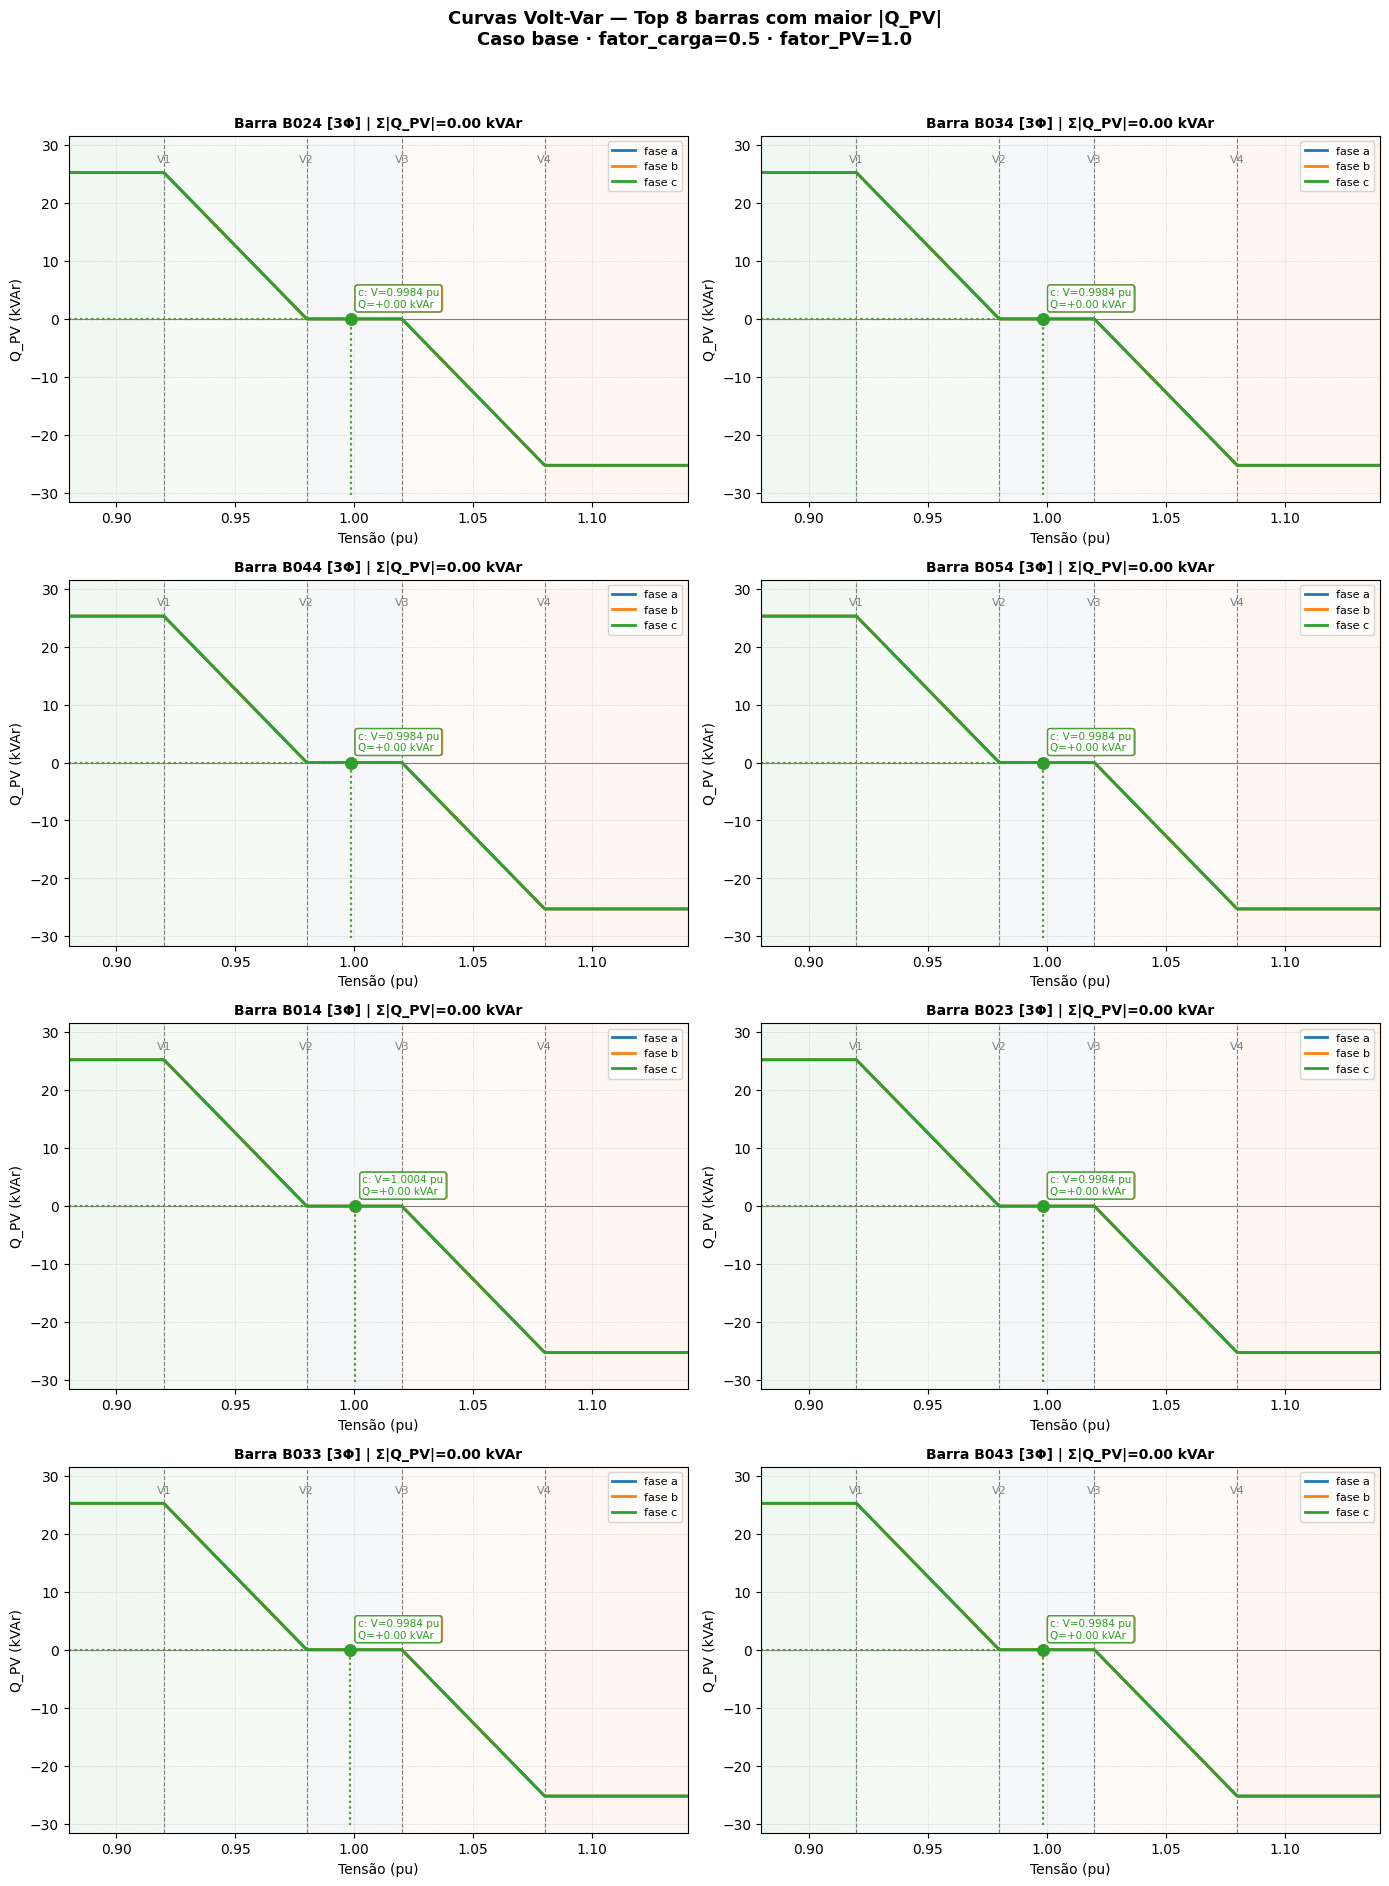

In [145]:
plot_voltvar_top_n_barras(
    model=model,
    buses_bt=buses_bt,
    PHASES=PHASES,
    S_base_1ph=S_base_1ph,
    BUS_TYPE=BUS_TYPE,
    N=8,
    scenario_name="Caso base",
    load_factor=FATOR_CARGA,
    pv_factor=FATOR_PV,
    save_path="voltvar_top8_barras.png"
)